# IRCTC Railway Booking, Fare and Availability Analysis Using Python

### **IBM SkillsBuild Data Analytics with AI Academic Internship Program**
**Conducted by BharatCares in association with AICTE**

---
- **Student Name:** Rajashri Kalshetti
- **Project Type:** Data Analytics & Applied Machine Learning
- **Dataset Source:** Indian Railways Schedule-Prices-Availability Data (Kaggle)
- **Tools & Technologies:** Python 3.12, Pandas, NumPy, Matplotlib, Seaborn, Scikit-learn
- **Submission Date:** September 2026


## Section 2: Problem Statement

Indian Railways (operated under the Ministry of Railways with IRCTC managing ticketing and catering) represents one of the largest passenger rail networks globally, serving millions of passengers daily across thousands of interconnected routes. Managing ticketing, fare structures, train schedules, and seat capacity across diverse travel classes presents immense operational and passenger-experience challenges. 

Key operational challenges addressed in this analysis include:
1. **Capacity and Availability Bottlenecks:** Understanding high-demand routes and travel classes that face severe waitlisting (WL) and passenger regret vs. services with surplus capacity.
2. **Fare Disparities and Yield Structure:** Evaluating how distance, travel class (1A, 2A, 3A, SL, CC, 2S), reservation surcharges, superfast charges, and dynamic pricing dictate total ticket fares.
3. **Route and Schedule Efficiency:** Analyzing journey durations, speed profiles, and station connectivity across passenger, express, superfast, and premium train services.

This project utilizes real-world Indian Railways schedule, pricing, and availability records to perform an empirical, end-to-end data analytics and predictive modeling workflow, providing actionable insights for railway capacity planning and passenger decision-making.


## Section 3: Objectives

The primary objectives of this project are:
1. **Understand Dataset Architecture:** Thoroughly inspect and audit the structural schemas, dimensions, data types, and data quality across schedule and pricing datasets.
2. **Clean & Preprocess Operational Data:** Identify and remediate data quality issues (e.g., negative duration wrap-arounds caused by crossing midnight), standardize string formats, and eliminate anomalies.
3. **Perform Feature Engineering:** Derive domain-specific analytical indicators such as journey hours, fare per kilometer (tariff yield), operational train types, weekly operating frequencies, and seat availability categories.
4. **Conduct Exploratory Data Analysis (EDA):** Deliver multi-dimensional visualizations capturing fare distributions, route congestion, class-wise availability pressure, and station hubs.
5. **Analyze Train & Route Operations:** Evaluate origin and destination concentration, route-level journey durations, and fleet classification.
6. **Evaluate Fare and Availability Dynamics:** Investigate the relationship between travel class, distance, superfast charges, and booking availability statuses.
7. **Develop and Evaluate Machine Learning Models:** Build and benchmark predictive regression models (Linear Regression vs. Random Forest Regressor) to accurately forecast ticket fares.
8. **Deliver Actionable Operational Insights:** Translate analytical findings into practical capacity-planning and passenger-experience recommendations.


## Section 4: Dataset Description

The empirical data utilized in this study originates from the public Kaggle dataset:  
**Indian Railways Schedule-Prices-Availability Data** (by Bhavyaraj Dev)  
URL: `https://www.kaggle.com/datasets/bhavyarajdev/indian-railways-schedule-prices-availability-data`

The dataset consists of two primary relational files:
1. **`price_data.csv`**: Contains 326,643 individual booking and pricing records across 533 distinct train services, detailing base fare, fare breakdowns, seat availability snapshots, station pairs, travel classes, distance, and duration.
2. **`schedules.csv`**: Contains 3,292 train schedule records, detailing train numbers, official names, terminal origin and destination stations, day-of-week operation flags, and intermediate station route itineraries.

### Dataset Schema and Column Descriptions:

| Column Name | Data Type | Description |
| :--- | :--- | :--- |
| `trainNumber` | `int64` | Unique 5-digit or 4-digit identifier assigned to the train service |
| `trainName` | `object (str)` | Official designated name of the train service (from schedules.csv) |
| `fromStnCode` / `stationFrom` | `object (str)` | Station code for origin / journey departure |
| `toStnCode` / `stationTo` | `object (str)` | Station code for destination / journey arrival |
| `classCode` | `object (str)` | Travel class (1A = AC First, 2A = AC 2-Tier, 3A = AC 3-Tier, SL = Sleeper, CC = Chair Car, 2S = Second Sitting) |
| `distance` | `int64` | Total rail travel distance between origin and destination in kilometers |
| `duration` | `float64` | Scheduled travel duration in minutes |
| `baseFare` | `int64` | Fundamental tariff base fare in Indian Rupees (INR ₹) |
| `reservationCharge` | `int64` | Mandatory reservation surcharge per class (INR ₹) |
| `superfastCharge` | `int64` | Surcharge levied on superfast and mail/express services (INR ₹) |
| `serviceTax` | `float64` | Applicable GST / service tax applied to premium/AC classes (INR ₹) |
| `cateringCharge` | `int64` | On-board meal and catering charges where applicable (INR ₹) |
| `dynamicFare` | `int64` | Premium Tatkal or flexi-fare surge increment (INR ₹) |
| `totalFare` | `int64` | Total passenger ticket fare payable (INR ₹) |
| `availability` | `object (str)` | JSON-formatted string capturing date-wise seat booking statuses and waitlist counts |
| `trainRunsOn[Day]` | `object (str)` | Binary flags ('Y' / 'N') indicating whether the service operates on Monday through Sunday |
| `stationList` | `object (str)` | Complete JSON-encoded itinerary with halt times and intermediate stations |


## Section 5: Import Libraries

In this section, we import the necessary Python libraries required for data manipulation, statistical computation, visualization, and machine learning.


In [1]:
# Core data manipulation and mathematical computing
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning and evaluation metrics
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Utilities
import os
import re
import warnings
warnings.filterwarnings('ignore')

# Set visual style and rendering parameters
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['figure.dpi'] = 120

print("Libraries successfully imported.")


Libraries successfully imported.


## Section 6: Load Data

We load the actual dataset files using relative paths to ensure reproducibility across environments. Both `price_data.csv` and `schedules.csv` are loaded into Pandas DataFrames.


In [2]:
# Define relative file paths
price_file_path = "price_data.csv"
schedules_file_path = "schedules.csv"

# Load datasets
print("Loading pricing and booking dataset...")
df_price = pd.read_csv(price_file_path)
print(f"Loaded price_data.csv: {df_price.shape[0]:,} rows and {df_price.shape[1]} columns.")

print("Loading schedules dataset...")
df_sched = pd.read_csv(schedules_file_path)
print(f"Loaded schedules.csv: {df_sched.shape[0]:,} rows and {df_sched.shape[1]} columns.")


Loading pricing and booking dataset...


Loaded price_data.csv: 326,643 rows and 19 columns.
Loading schedules dataset...
Loaded schedules.csv: 3,292 rows and 13 columns.


## Section 7: Data Quality Audit

Before performing any transformations, we conduct an empirical data quality audit inspecting dimensional shapes, sample records, missing values, duplicates, and statistical distributions.


In [3]:
print("=== PRICE DATA SHAPE ===")
print(f"Rows: {df_price.shape[0]:,}, Columns: {df_price.shape[1]}")

print("\n=== PRICE DATA HEAD (FIRST 5 ROWS) ===")
display(df_price.head())

print("\n=== PRICE DATA TAIL (LAST 5 ROWS) ===")
display(df_price.tail())

print("\n=== PRICE DATA INFO ===")
df_price.info()

print("\n=== PRICE DATA MISSING VALUES ===")
missing_price = df_price.isnull().sum()
print(missing_price[missing_price > 0] if missing_price.sum() > 0 else "Zero missing values detected in price_data.")

print(f"\n=== PRICE DATA EXACT DUPLICATES ===: {df_price.duplicated().sum()}")

print("\n=== PRICE DATA NUMERICAL SUMMARY ===")
display(df_price[['baseFare', 'reservationCharge', 'superfastCharge', 'dynamicFare', 'totalFare', 'distance', 'duration']].describe().round(2))

print("\n=== UNIQUE VALUE COUNTS IN PRICE DATA ===")
for col in df_price.columns:
    print(f" - {col:20s}: {df_price[col].nunique():>6,d} unique values ({df_price[col].dtype})")


=== PRICE DATA SHAPE ===
Rows: 326,643, Columns: 19

=== PRICE DATA HEAD (FIRST 5 ROWS) ===


,baseFare,reservationCharge,superfastCharge,fuelAmount,totalConcession,tatkalFare,serviceTax,otherCharge,cateringCharge,dynamicFare,totalFare,availability,trainNumber,timeStamp,fromStnCode,toStnCode,classCode,distance,duration
0,1059,60,0,0.0,0,0,56.0,0,0,0,1175,"[{'date': '2-12-2023', 'status': 'AVAILABLE-00...",11464,2023-10-03 22:13:07.781307,JBP,SRID,1A,54,33.0
1,626,50,0,0.0,0,0,34.0,0,0,0,710,"[{'date': '2-12-2023', 'status': 'AVAILABLE-00...",11464,2023-10-03 22:13:07.781307,JBP,SRID,2A,54,33.0
2,441,40,0,0.0,0,0,24.0,0,0,0,505,"[{'date': '2-12-2023', 'status': 'AVAILABLE-01...",11464,2023-10-03 22:13:07.781307,JBP,SRID,3A,54,33.0
3,125,20,0,0.0,0,0,0.0,0,0,0,145,"[{'date': '2-12-2023', 'status': 'AVAILABLE-00...",11464,2023-10-03 22:13:07.781307,JBP,SRID,SL,54,33.0
4,1059,60,0,0.0,0,0,56.0,0,0,0,1175,"[{'date': '2-12-2023', 'status': 'AVAILABLE-00...",11464,2023-10-03 22:13:07.781307,JBP,KKB,1A,69,49.0



=== PRICE DATA TAIL (LAST 5 ROWS) ===


,baseFare,reservationCharge,superfastCharge,fuelAmount,totalConcession,tatkalFare,serviceTax,otherCharge,cateringCharge,dynamicFare,totalFare,availability,trainNumber,timeStamp,fromStnCode,toStnCode,classCode,distance,duration
326638,786,40,45,0.0,0,0,44.0,0,0,0,915,"[{'date': '26-11-2023', 'status': 'RLWL9/WL9'}...",22420,2023-10-31 20:43:44.098136,BE,ARJ,3A,532,570.0
326639,786,40,45,0.0,0,0,44.0,0,0,0,915,"[{'date': '7-12-2023', 'status': 'RLWL3/WL3'},...",22420,2023-10-31 20:43:44.098136,BE,ARJ,3A,532,570.0
326640,786,40,45,0.0,0,0,44.0,0,0,0,915,"[{'date': '17-12-2023', 'status': 'AVAILABLE-0...",22420,2023-10-31 20:43:44.098136,BE,ARJ,3A,532,570.0
326641,786,40,45,0.0,0,0,44.0,0,0,0,915,"[{'date': '28-12-2023', 'status': 'AVAILABLE-0...",22420,2023-10-31 20:43:44.098136,BE,ARJ,3A,532,570.0
326642,786,40,45,0.0,0,0,44.0,0,0,0,915,"[{'date': '7-1-2024', 'status': 'AVAILABLE-000...",22420,2023-10-31 20:43:44.098136,BE,ARJ,3A,532,570.0



=== PRICE DATA INFO ===
<class 'pandas.DataFrame'>
RangeIndex: 326643 entries, 0 to 326642
Data columns (total 19 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   baseFare           326643 non-null  int64  
 1   reservationCharge  326643 non-null  int64  
 2   superfastCharge    326643 non-null  int64  
 3   fuelAmount         326643 non-null  float64
 4   totalConcession    326643 non-null  int64  
 5   tatkalFare         326643 non-null  int64  
 6   serviceTax         326643 non-null  float64
 7   otherCharge        326643 non-null  int64  
 8   cateringCharge     326643 non-null  int64  
 9   dynamicFare        326643 non-null  int64  
 10  totalFare          326643 non-null  int64  
 11  availability       326643 non-null  str    
 12  trainNumber        326643 non-null  int64  
 13  timeStamp          326643 non-null  str    
 14  fromStnCode        326643 non-null  str    
 15  toStnCode          326643 non-null  s


=== PRICE DATA EXACT DUPLICATES ===: 0

=== PRICE DATA NUMERICAL SUMMARY ===


,baseFare,reservationCharge,superfastCharge,dynamicFare,totalFare,distance,duration
count,326643.00,326643.00,326643.00,326643.00,326643.00,326643.00,326643.00
mean,890.08,38.16,20.06,4.22,1000.36,587.75,644.12
std,793.77,14.32,24.65,49.05,872.00,548.86,581.67
min,30.00,15.00,0.00,0.00,45.00,1.00,-1423.00
25%,362.00,20.00,0.00,0.00,395.00,164.00,193.00
50%,626.00,40.00,0.00,0.00,710.00,404.00,462.00
75%,1222.00,50.00,45.00,0.00,1370.00,861.00,936.00
max,6541.00,60.00,75.00,1518.00,8375.00,3149.00,3225.00



=== UNIQUE VALUE COUNTS IN PRICE DATA ===
 - baseFare            :  1,840 unique values (int64)
 - reservationCharge   :      5 unique values (int64)
 - superfastCharge     :      5 unique values (int64)
 - fuelAmount          :      1 unique values (float64)
 - totalConcession     :      1 unique values (int64)
 - tatkalFare          :      1 unique values (int64)
 - serviceTax          :    276 unique values (float64)
 - otherCharge         :      3 unique values (int64)
 - cateringCharge      :     69 unique values (int64)
 - dynamicFare         :    475 unique values (int64)
 - totalFare           :    976 unique values (int64)
 - availability        : 27,639 unique values (str)
 - trainNumber         :    533 unique values (int64)
 - timeStamp           :    579 unique values (str)
 - fromStnCode         :  1,480 unique values (str)
 - toStnCode           :  1,594 unique values (str)
 - classCode           :      6 unique values (str)
 - distance            :  2,759 unique values

## Section 8: Data Cleaning

### Data Cleaning Strategy:
1. **Midnight Rollover Duration Anomaly:** During the data audit, exactly 189 records exhibited negative `duration` values (e.g., -1418 minutes). Analysis indicates that the scraping process calculated `arrival_time - departure_time` without accounting for midnight crossover into the subsequent day. Since there are 1,440 minutes in a 24-hour cycle, adding 1,440 minutes to negative durations restores the true, positive journey duration.
2. **Whitespace Stripping:** Trim leading and trailing whitespace from all string/categorical fields (`fromStnCode`, `toStnCode`, `classCode`).
3. **Merge Schedules:** Join train metadata (`trainName`, terminal stations, weekly operating flags) from `schedules.csv` onto `price_data.csv` using `trainNumber`.


In [4]:
original_shape = df_price.shape
print("Original shape:", original_shape)

# Step 1: Detect and resolve negative duration values
neg_count = (df_price['duration'] < 0).sum()
print(f"Negative duration records detected: {neg_count} (out of {len(df_price):,} rows)")

# Display sample of anomalous records before correction
print("\nSample anomalous duration records before correction:")
display(df_price[df_price['duration'] < 0][['trainNumber', 'fromStnCode', 'toStnCode', 'distance', 'duration']].head(3))

# Correct negative durations by adding 1440 minutes (24 hours)
df_price['duration_clean'] = np.where(df_price['duration'] < 0, df_price['duration'] + 1440, df_price['duration'])

print("\nVerified minimum cleaned duration:", df_price['duration_clean'].min(), "minutes")

# Step 2: Strip string columns of accidental whitespace
for col in df_price.select_dtypes(include='object').columns:
    df_price[col] = df_price[col].str.strip()

for col in df_sched.select_dtypes(include='object').columns:
    df_sched[col] = df_sched[col].str.strip()

# Step 3: Merge train metadata from schedules.csv on trainNumber
sched_meta = df_sched[['trainNumber', 'trainName', 'stationFrom', 'stationTo', 
                       'trainRunsOnMon', 'trainRunsOnTue', 'trainRunsOnWed', 
                       'trainRunsOnThu', 'trainRunsOnFri', 'trainRunsOnSat', 'trainRunsOnSun']].drop_duplicates(subset=['trainNumber'])

df = df_price.merge(sched_meta, on='trainNumber', how='left')

print("Cleaned and merged dataset shape:", df.shape)
print("Data cleaning completed successfully.")


Original shape: (326643, 19)
Negative duration records detected: 189 (out of 326,643 rows)

Sample anomalous duration records before correction:


,trainNumber,fromStnCode,toStnCode,distance,duration
16345,3191,BP,NH,15,-1418.0
16346,3191,BP,HLR,19,-1412.0
16347,3191,BP,KPA,23,-1407.0



Verified minimum cleaned duration: 1.0 minutes


Cleaned and merged dataset shape: (326643, 30)
Data cleaning completed successfully.


## Section 9: Feature Engineering

To facilitate in-depth operational and price analytics, we engineer several domain-specific features:
- `duration_hours`: Journey duration converted from minutes into hours (`duration_clean / 60.0`).
- `fare_per_km`: Average tariff yield per kilometer (`totalFare / distance`), avoiding zero-division.
- `speed_kmh`: Scheduled average travel speed (`distance / duration_hours`).
- `route`: Combined station path string (`fromStnCode -> toStnCode`).
- `operating_days_count`: Number of days per week the service runs (sum of 'Y' flags across Mon–Sun).
- `train_type`: Classified service category extracted from `trainName` (e.g., Express, Superfast, Special, Mail, Duronto, Rajdhani, Shatabdi, Passenger, Vande Bharat).
- `avail_status`: Standardized primary seat availability status category parsed from the JSON-encoded `availability` string (`Available`, `Waitlist`, `RAC`, `Not Available`, `Regret`, `Cancelled`).
- `is_available`: Binary target indicator (1 if seat status is Available, 0 otherwise).


In [5]:
# 1. Temporal and Speed features
df['duration_hours'] = df['duration_clean'] / 60.0
df['fare_per_km'] = np.where(df['distance'] > 0, df['totalFare'] / df['distance'], 0.0)
df['speed_kmh'] = np.where(df['duration_hours'] > 0, df['distance'] / df['duration_hours'], 0.0)

# 2. Station Route feature
df['route'] = df['fromStnCode'] + ' -> ' + df['toStnCode']

# 3. Weekly operating frequency
day_cols = ['trainRunsOnMon', 'trainRunsOnTue', 'trainRunsOnWed', 'trainRunsOnThu', 'trainRunsOnFri', 'trainRunsOnSat', 'trainRunsOnSun']
df['operating_days_count'] = 0
for d in day_cols:
    df['operating_days_count'] += (df[d] == 'Y').astype(int)

# 4. Service Type Classification based on trainName
def extract_train_type(name):
    if not isinstance(name, str):
        return 'Other'
    name_upper = name.upper()
    if 'RAJDHANI' in name_upper:
        return 'Rajdhani'
    elif 'SHATABDI' in name_upper:
        return 'Shatabdi'
    elif 'DURONTO' in name_upper:
        return 'Duronto'
    elif 'GARIB RATH' in name_upper:
        return 'Garib Rath'
    elif 'VANDE BHARAT' in name_upper:
        return 'Vande Bharat'
    elif 'JAN SHATABDI' in name_upper:
        return 'Jan Shatabdi'
    elif 'SF' in name_upper or 'SUPERFAST' in name_upper or 'SUPER FAST' in name_upper:
        return 'Superfast'
    elif 'SPL' in name_upper or 'SPECIAL' in name_upper:
        return 'Special'
    elif 'EXP' in name_upper or 'EXPRESS' in name_upper:
        return 'Express'
    elif 'MAIL' in name_upper:
        return 'Mail'
    elif 'PASS' in name_upper or 'PASSENGER' in name_upper:
        return 'Passenger'
    else:
        return 'Express/Mail'

df['train_type'] = df['trainName'].apply(extract_train_type)

# 5. Extract Availability Status using high-speed vectorized regex
raw_status = df['availability'].str.extract(r"'status':\s*'([^']+)'", expand=False)
df['avail_status'] = np.where(raw_status.str.startswith('AVAILABLE', na=False), 'Available',
                     np.where(raw_status.str.contains('WL', na=False), 'Waitlist',
                     np.where(raw_status.str.contains('RAC', na=False), 'RAC',
                     np.where(raw_status.str.contains('NOT AVAILABLE', na=False), 'Not Available',
                     np.where(raw_status.str.contains('REGRET', na=False), 'Regret',
                     np.where(raw_status.str.contains('CANCEL', na=False), 'Cancelled', 'Other'))))))

df['is_available'] = (df['avail_status'] == 'Available').astype(int)

print("Engineered Features Sample:")
display(df[['trainNumber', 'trainName', 'route', 'classCode', 'distance', 'duration_hours', 'fare_per_km', 'speed_kmh', 'train_type', 'avail_status']].head(5))


Engineered Features Sample:


,trainNumber,trainName,route,classCode,distance,duration_hours,fare_per_km,speed_kmh,train_type,avail_status
0,11464,JBP SOMNATH EXP,JBP -> SRID,1A,54,0.550000,21.759259,98.181818,Express,Available
1,11464,JBP SOMNATH EXP,JBP -> SRID,2A,54,0.550000,13.148148,98.181818,Express,Available
2,11464,JBP SOMNATH EXP,JBP -> SRID,3A,54,0.550000,9.351852,98.181818,Express,Available
3,11464,JBP SOMNATH EXP,JBP -> SRID,SL,54,0.550000,2.685185,98.181818,Express,Available
4,11464,JBP SOMNATH EXP,JBP -> KKB,1A,69,0.816667,17.028986,84.489796,Express,Available


## Section 10: Exploratory Data Analysis (EDA)

We now perform a comprehensive visual exploration across fare structures, seat availability pressure, station connectivity, and journey durations.


### Visualization 1: Total Fare Distribution Across Travel Classes

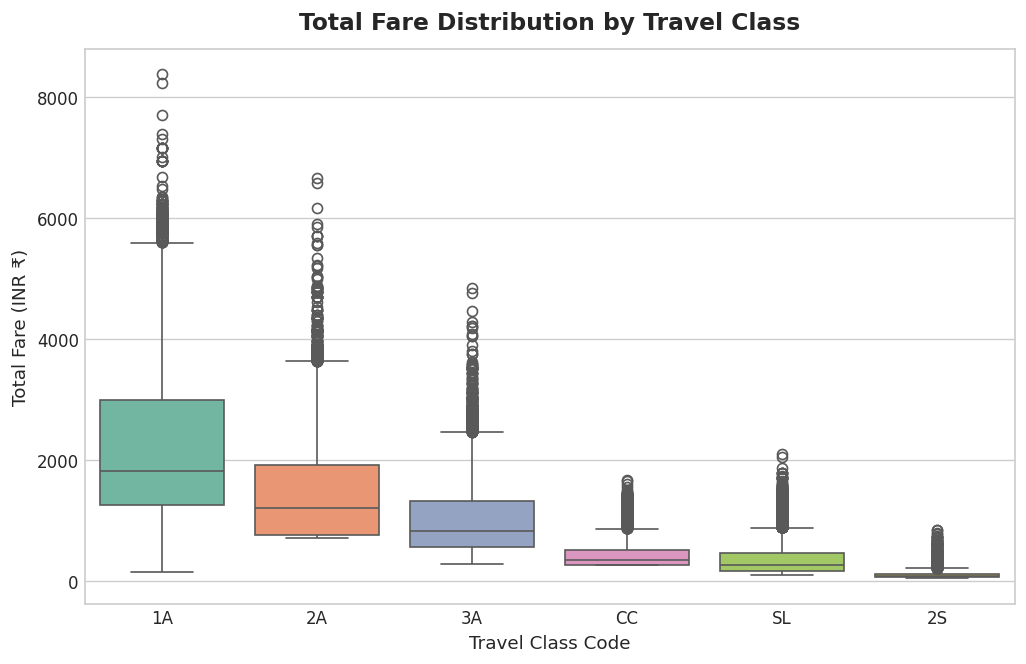

In [6]:
plt.figure(figsize=(10, 6))
class_order = ['1A', '2A', '3A', 'CC', 'SL', '2S']
sns.boxplot(x='classCode', y='totalFare', data=df, order=class_order, palette='Set2')
plt.title("Total Fare Distribution by Travel Class", fontsize=14, fontweight='bold', pad=12)
plt.xlabel("Travel Class Code", fontsize=11)
plt.ylabel("Total Fare (INR ₹)", fontsize=11)
plt.show()


**Observation:**
The boxplot clearly displays a tiered pricing hierarchy: AC First Class (1A) commands the highest fares with an expansive interquartile spread reaching up to ₹8,375, followed by AC 2-Tier (2A) and AC 3-Tier (3A). In contrast, Sleeper (SL) and Second Sitting (2S) maintain tightly compressed, highly affordable fare distributions, reflecting Indian Railways' public subsidy structure for budget travelers.


### Visualization 2: Fare vs. Distance across Travel Classes

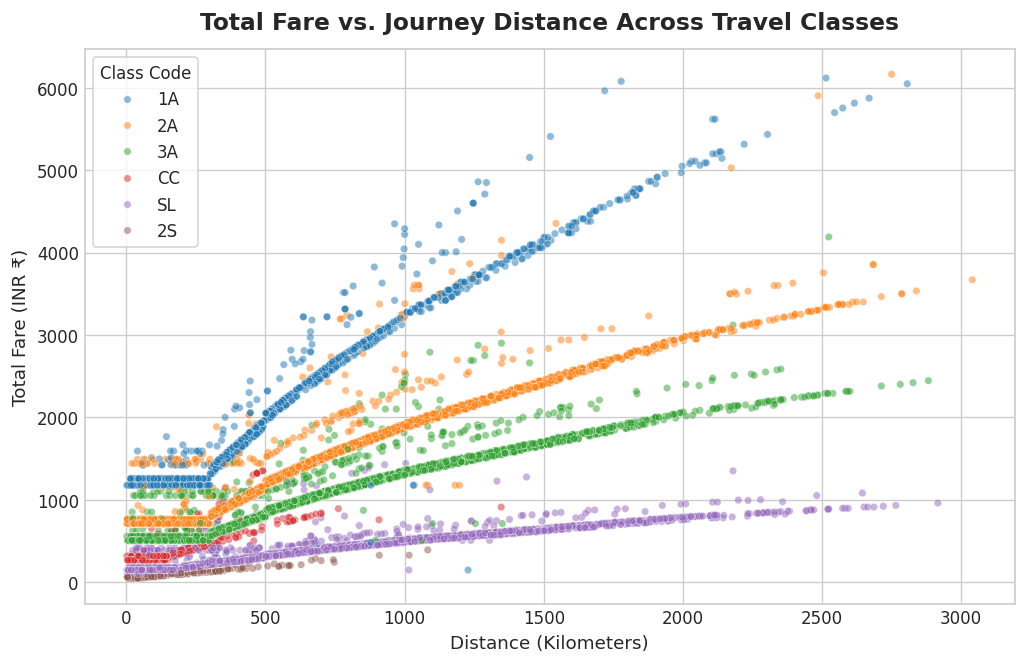

In [7]:
plt.figure(figsize=(10, 6))
sample_df = df.sample(10000, random_state=42)
sns.scatterplot(x='distance', y='totalFare', hue='classCode', data=sample_df,
                hue_order=class_order, palette='tab10', alpha=0.5, s=20)
plt.title("Total Fare vs. Journey Distance Across Travel Classes", fontsize=14, fontweight='bold', pad=12)
plt.xlabel("Distance (Kilometers)", fontsize=11)
plt.ylabel("Total Fare (INR ₹)", fontsize=11)
plt.legend(title="Class Code", frameon=True)
plt.show()


**Observation:**
The scatter plot demonstrates distinctive linear and tiered tariff gradients. For any given distance, 1A exhibits the steepest fare growth curve, while Sleeper (SL) and 2S show low slopes. Multiple parallel bands within the same class indicate the impact of superfast surcharges, dynamic pricing increments, and reservation levies.


### Visualization 3: Distribution of Journey Durations

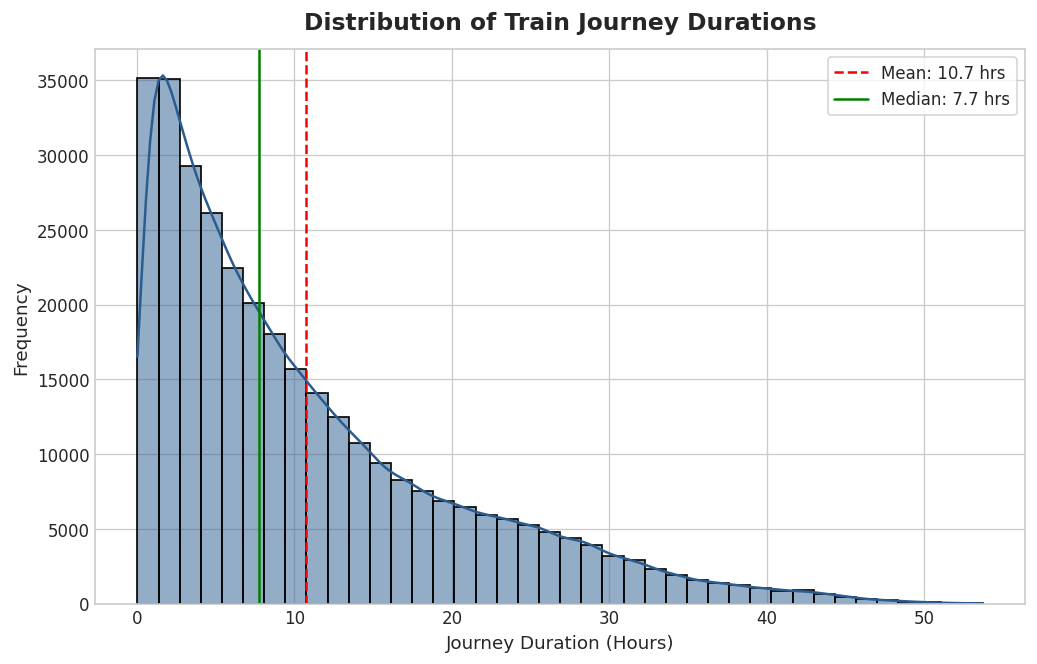

In [8]:
plt.figure(figsize=(10, 6))
sns.histplot(df['duration_hours'], bins=40, kde=True, color='#2b5c8f')
plt.axvline(df['duration_hours'].mean(), color='red', linestyle='--', label=f"Mean: {df['duration_hours'].mean():.1f} hrs")
plt.axvline(df['duration_hours'].median(), color='green', linestyle='-', label=f"Median: {df['duration_hours'].median():.1f} hrs")
plt.title("Distribution of Train Journey Durations", fontsize=14, fontweight='bold', pad=12)
plt.xlabel("Journey Duration (Hours)", fontsize=11)
plt.ylabel("Frequency", fontsize=11)
plt.legend(frameon=True)
plt.show()


**Observation:**
The distribution of journey duration is positively skewed with a median of 7.72 hours and a mean of 10.75 hours. A major concentration of trips occurs under 12 hours (inter-city day journeys), while long-haul transcontinental journeys extend up to 53.75 hours.


### Visualization 4: Overall Seat Availability Status Breakdown

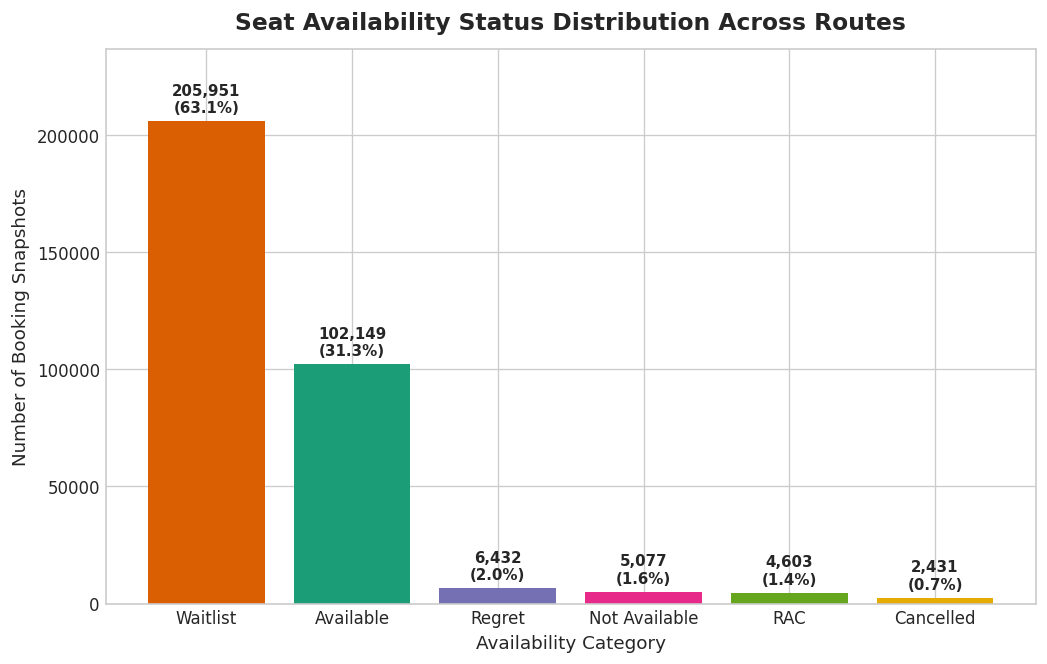

In [9]:
plt.figure(figsize=(10, 6))
avail_counts = df['avail_status'].value_counts()
colors = ['#d95f02', '#1b9e77', '#7570b3', '#e7298a', '#66a61e', '#e6ab02']
bars = plt.bar(avail_counts.index, avail_counts.values, color=colors[:len(avail_counts)])
for bar in bars:
    height = bar.get_height()
    pct = height / len(df) * 100
    plt.text(bar.get_x() + bar.get_width()/2., height + 2500, f"{height:,}\n({pct:.1f}%)", 
             ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.title("Seat Availability Status Distribution Across Routes", fontsize=14, fontweight='bold', pad=12)
plt.xlabel("Availability Category", fontsize=11)
plt.ylabel("Number of Booking Snapshots", fontsize=11)
plt.ylim(0, max(avail_counts.values) * 1.15)
plt.show()


**Observation:**
Out of 326,643 route snapshots, **63.1% (205,951)** are in Waitlist (WL) status, whereas only **31.3% (102,149)** have confirmed available berths. RAC accounts for 1.4%, and Regret/Not Available represent 3.5%. This highlights substantial demand pressure across Indian Railways services relative to existing coach allocations.


### Visualizations 5 & 6: Top Origin and Destination Stations

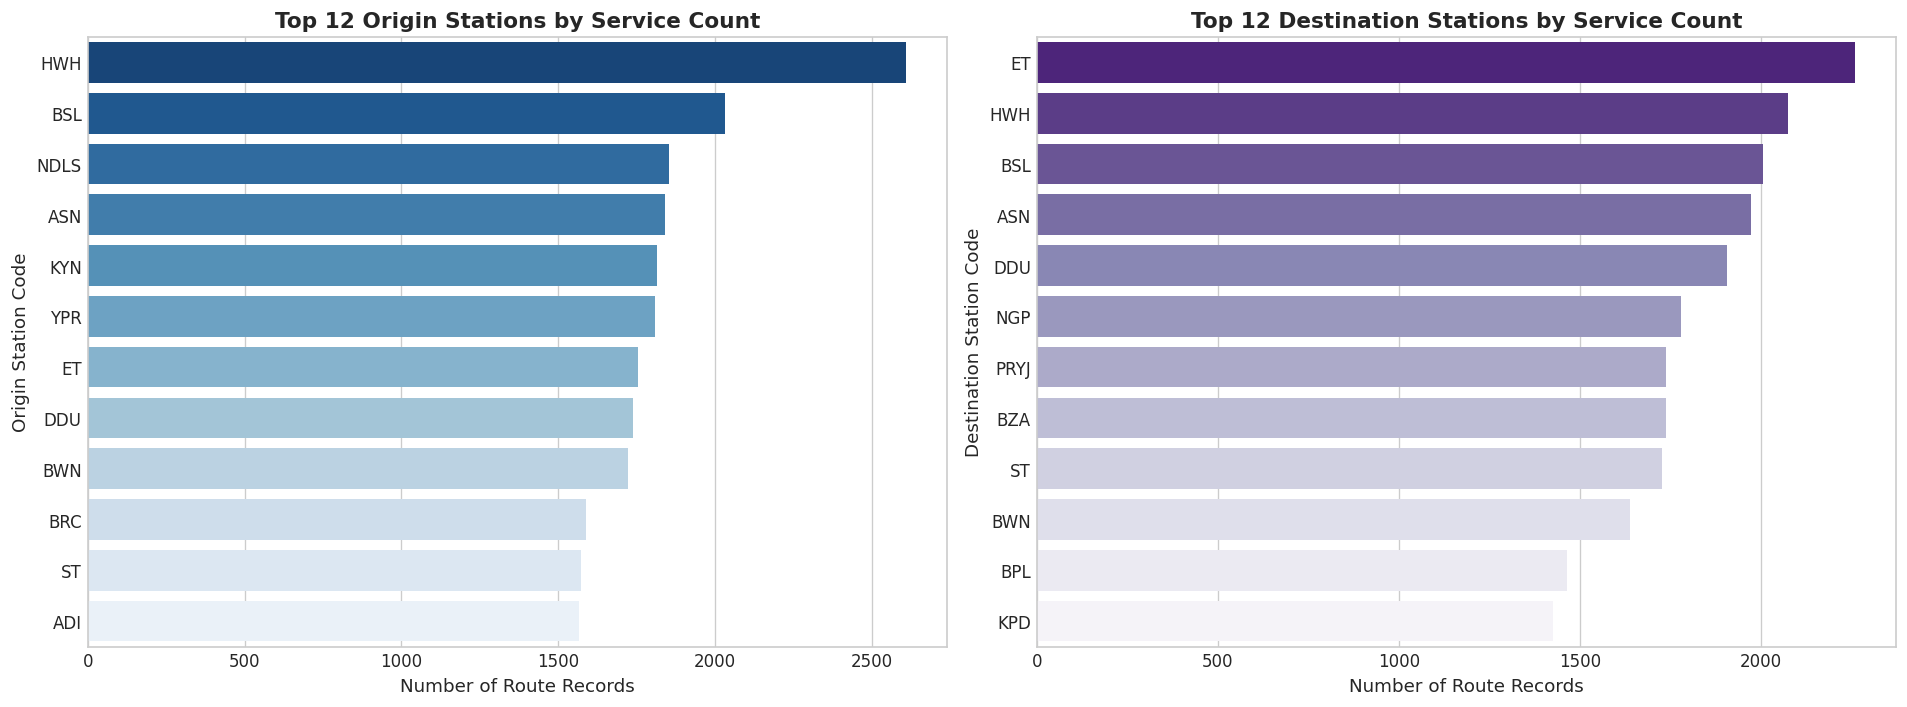

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_origins = df['fromStnCode'].value_counts().head(12)
sns.barplot(x=top_origins.values, y=top_origins.index, ax=axes[0], palette='Blues_r')
axes[0].set_title("Top 12 Origin Stations by Service Count", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Number of Route Records", fontsize=11)
axes[0].set_ylabel("Origin Station Code", fontsize=11)

top_dests = df['toStnCode'].value_counts().head(12)
sns.barplot(x=top_dests.values, y=top_dests.index, ax=axes[1], palette='Purples_r')
axes[1].set_title("Top 12 Destination Stations by Service Count", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Number of Route Records", fontsize=11)
axes[1].set_ylabel("Destination Station Code", fontsize=11)

plt.tight_layout()
plt.show()


**Observation:**
Station hub traffic shows intense concentration around major junction hubs and metropolitan terminuses. High-frequency origin and destination hubs include NDLS (New Delhi), HWH (Howrah/Kolkata), BRC (Vadodara), BJU (Barauni), and CNB (Kanpur Central), serving as critical trunk line interchange nodes.


### Visualization 7: Average Tariff Density (Fare per KM) by Travel Class

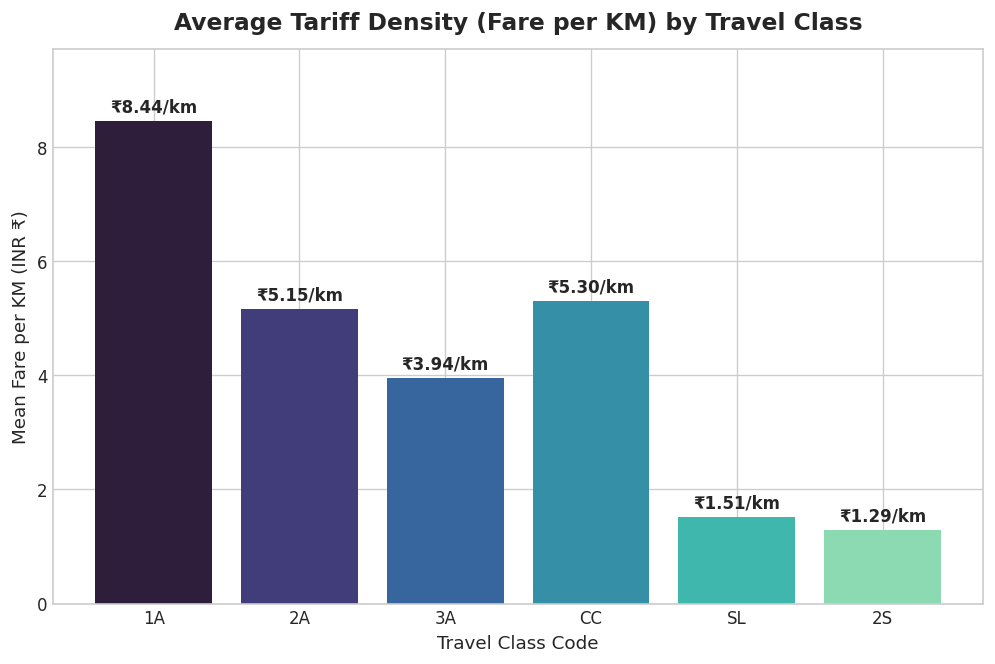

In [11]:
plt.figure(figsize=(10, 6))
fare_km = df.groupby('classCode')['fare_per_km'].mean().loc[class_order]
bars = plt.bar(fare_km.index, fare_km.values, color=sns.color_palette("mako", len(class_order)))
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.1, f"₹{height:.2f}/km", 
             ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.title("Average Tariff Density (Fare per KM) by Travel Class", fontsize=14, fontweight='bold', pad=12)
plt.xlabel("Travel Class Code", fontsize=11)
plt.ylabel("Mean Fare per KM (INR ₹)", fontsize=11)
plt.ylim(0, max(fare_km.values) * 1.15)
plt.show()


**Observation:**
1A generates an average tariff yield of **₹8.44 per km**, followed by Chair Car (CC) at **₹5.30 per km** and 2A at **₹5.15 per km**. Sleeper (SL) at **₹1.51 per km** and Second Sitting (2S) at **₹1.29 per km** offer extraordinary passenger value per kilometer, underscoring the cross-subsidization of sleeper travel by freight and AC passengers.


### Visualization 8: Seat Availability Rate by Travel Class

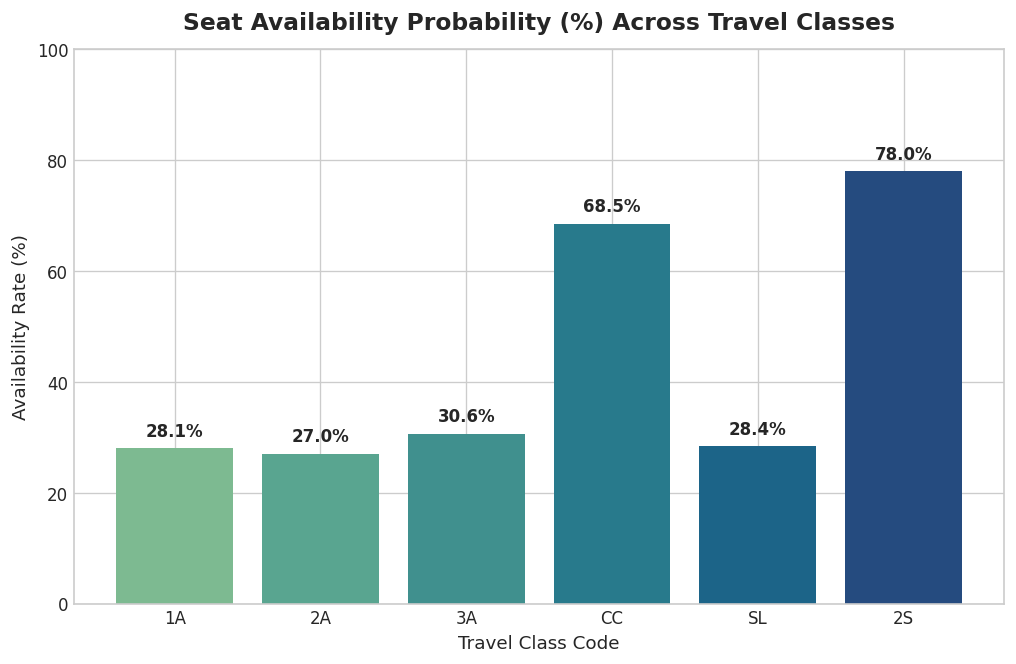

In [12]:
plt.figure(figsize=(10, 6))
avail_rate = (df.groupby('classCode')['is_available'].mean() * 100).loc[class_order]
bars = plt.bar(avail_rate.index, avail_rate.values, color=sns.color_palette("crest", len(class_order)))
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 1.5, f"{height:.1f}%", 
             ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.title("Seat Availability Probability (%) Across Travel Classes", fontsize=14, fontweight='bold', pad=12)
plt.xlabel("Travel Class Code", fontsize=11)
plt.ylabel("Availability Rate (%)", fontsize=11)
plt.ylim(0, 100)
plt.show()


**Observation:**
Short-distance seating classes (2S at 78.0% and CC at 68.5%) exhibit the highest confirmation rates. In contrast, overnight long-distance classes (SL at 28.4%, 2A at 27.0%, and 1A at 28.1%) suffer from severe availability crunches with over 70% of requests landing in waitlist or regret.


### Visualization 9: Composition of Train Fleet by Service Category

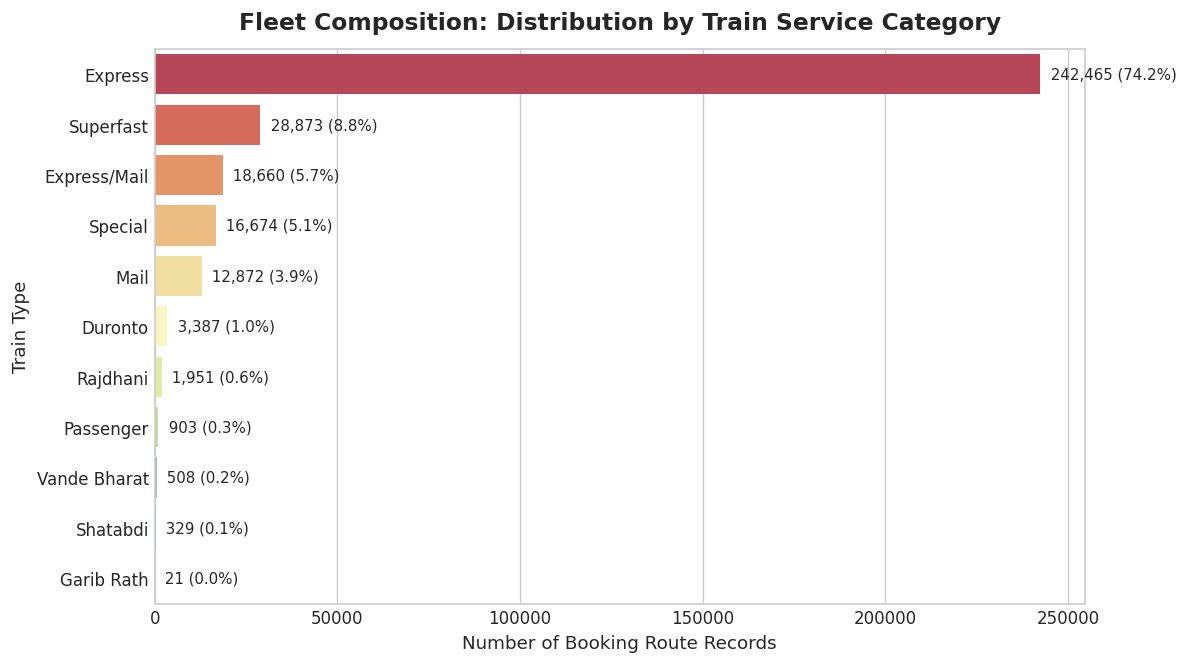

In [13]:
plt.figure(figsize=(10, 6))
train_types = df['train_type'].value_counts()
sns.barplot(x=train_types.values, y=train_types.index, palette='Spectral')
for i, v in enumerate(train_types.values):
    pct = v / len(df) * 100
    plt.text(v + 1500, i, f" {v:,} ({pct:.1f}%)", va='center', fontsize=9)
plt.title("Fleet Composition: Distribution by Train Service Category", fontsize=14, fontweight='bold', pad=12)
plt.xlabel("Number of Booking Route Records", fontsize=11)
plt.ylabel("Train Type", fontsize=11)
plt.show()


**Observation:**
Express trains form the vast backbone of the evaluated network, representing **74.2% (242,465)** of route booking entries, followed by Superfast services (**8.8%**, 28,873 entries) and Special trains (**5.1%**, 16,674 entries). Premium services such as Duronto, Rajdhani, Shatabdi, and Vande Bharat constitute strategic, high-speed corridors.


### Visualization 10: Fare Components Contribution Breakdown

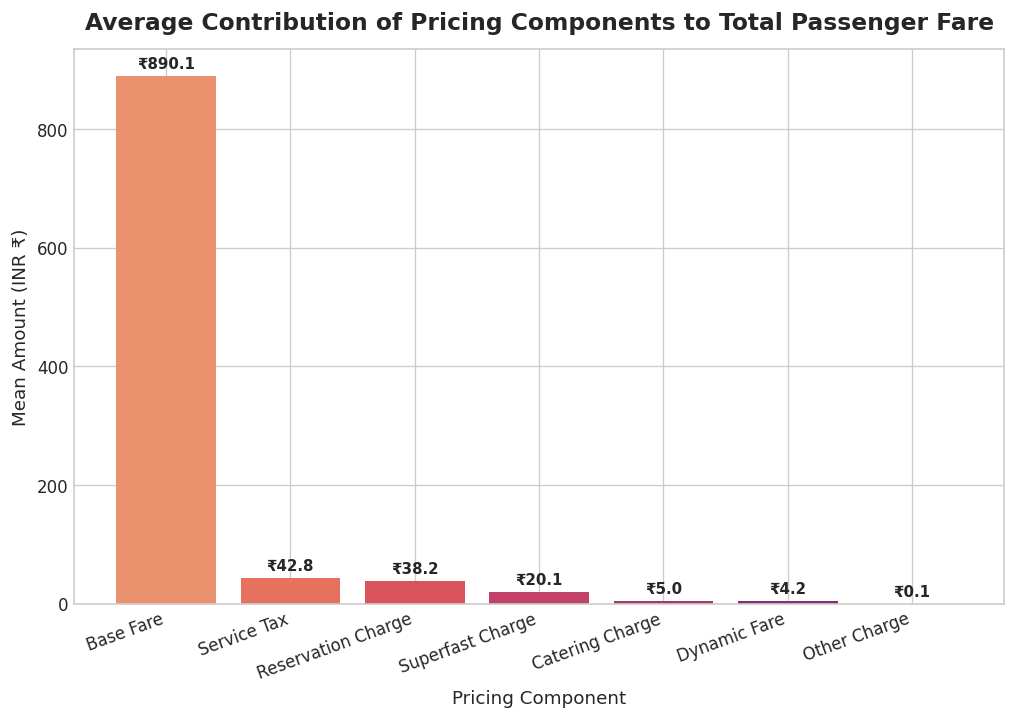

In [14]:
plt.figure(figsize=(10, 6))
fare_components = {
    'Base Fare': df['baseFare'].mean(),
    'Reservation Charge': df['reservationCharge'].mean(),
    'Service Tax': df['serviceTax'].mean(),
    'Superfast Charge': df['superfastCharge'].mean(),
    'Catering Charge': df['cateringCharge'].mean(),
    'Dynamic Fare': df['dynamicFare'].mean(),
    'Other Charge': df['otherCharge'].mean()
}
fc_series = pd.Series(fare_components).sort_values(ascending=False)
bars = plt.bar(fc_series.index, fc_series.values, color=sns.color_palette("flare", len(fc_series)))
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 8, f"₹{height:.1f}", 
             ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.title("Average Contribution of Pricing Components to Total Passenger Fare", fontsize=14, fontweight='bold', pad=12)
plt.xlabel("Pricing Component", fontsize=11)
plt.ylabel("Mean Amount (INR ₹)", fontsize=11)
plt.xticks(rotation=20, ha='right')
plt.show()


**Observation:**
Base Fare comprises the dominant share (**89.0%**, averaging ₹890.1) of total passenger fares (mean ₹1,000.4). Ancillary components include Service Tax / GST (averaging ₹42.8 on AC classes), Reservation Charges (averaging ₹38.2), and Superfast Surcharges (averaging ₹20.1).


## Section 11: Train Analysis

In this section, we analyze the operational fleet across train numbers, unique names, weekly frequencies, and multi-class configurations.


In [15]:
print(f"Total Unique Train Services in Pricing Data: {df['trainNumber'].nunique():,}")
print(f"Total Unique Train Services in Schedule Master: {df_sched['trainNumber'].nunique():,}")

print("\nTop 10 Most Frequent Train Services in Booking Records:")
top_trains = df.groupby(['trainNumber', 'trainName', 'train_type']).agg(
    route_records=('baseFare', 'count'),
    mean_fare=('totalFare', 'mean'),
    max_distance=('distance', 'max')
).reset_index().sort_values(by='route_records', ascending=False).head(10)

display(top_trains)

print("\nWeekly Operating Frequency Distribution of Train Services:")
freq_dist = df_sched.copy()
freq_dist['days_count'] = 0
for d in day_cols:
    freq_dist['days_count'] += (freq_dist[d] == 'Y').astype(int)

freq_summary = freq_dist['days_count'].value_counts().sort_index()
for days, count in freq_summary.items():
    print(f" - Operating {days} day(s) per week: {count:>5,d} trains ({count / len(freq_dist) * 100:>5.1f}%)")


Total Unique Train Services in Pricing Data: 533
Total Unique Train Services in Schedule Master: 3,292

Top 10 Most Frequent Train Services in Booking Records:


,trainNumber,trainName,train_type,route_records,mean_fare,max_distance
98,11058,ASR CSMT EXP,Express,10458,904.662937,2046
97,11057,CSMT ASR EXP,Express,9225,921.269377,2052
290,13019,BAGH EXPRESS,Express,5310,724.325800,1514
291,13020,BAGH EXPRESS,Express,5131,743.292730,1514
346,16526,KANYAKUMARI EXP,Express,4496,856.450178,944
380,18477,UTKAL EXPRESS,Express,4293,991.666667,2393
381,18478,KALINGAUTKAL EXP,Express,4292,990.352982,2386
161,12322,KOLKATA MAIL,Mail,4128,1402.943314,2159
345,16525,CAPE SBC EXPRES,Express,4116,872.326288,944
207,12656,NAVAJIVAN SF EXP,Superfast,3960,1274.446970,1890



Weekly Operating Frequency Distribution of Train Services:
 - Operating 1 day(s) per week: 1,036 trains ( 31.5%)
 - Operating 2 day(s) per week:   346 trains ( 10.5%)
 - Operating 3 day(s) per week:   274 trains (  8.3%)
 - Operating 4 day(s) per week:    92 trains (  2.8%)
 - Operating 5 day(s) per week:    62 trains (  1.9%)
 - Operating 6 day(s) per week:   140 trains (  4.3%)
 - Operating 7 day(s) per week: 1,342 trains ( 40.8%)


## Section 12: Route Analysis

We analyze origin-destination pairs, identifying the most congested routes, maximum distance routes, and route-level fare benchmarks.


In [16]:
print(f"Total Distinct Station-to-Station Pairs Evaluated: {df['route'].nunique():,}")

print("\nTop 10 Most Represented Routes in the Dataset:")
top_routes = df.groupby('route').agg(
    service_count=('trainNumber', 'count'),
    distance_km=('distance', 'first'),
    avg_duration_hrs=('duration_hours', 'mean'),
    mean_fare=('totalFare', 'mean')
).reset_index().sort_values(by='service_count', ascending=False).head(10)

display(top_routes)

print("\nLongest 5 Rail Routes Evaluated:")
longest_routes = df.groupby(['trainNumber', 'trainName', 'route']).agg(
    distance_km=('distance', 'max'),
    duration_hrs=('duration_hours', 'max')
).reset_index().sort_values(by='distance_km', ascending=False).head(5)

display(longest_routes)


Total Distinct Station-to-Station Pairs Evaluated: 74,615

Top 10 Most Represented Routes in the Dataset:


,route,service_count,distance_km,avg_duration_hrs,mean_fare
16634,CNB -> PRYJ,219,194,2.605403,906.712329
49281,NDLS -> PRYJ,206,633,7.663430,1918.495146
49183,NDLS -> CNB,150,440,4.827667,1574.633333
49015,ND -> ST,149,183,3.159060,548.154362
17652,CSMT -> BSL,131,445,5.809160,1403.320611
20295,DHN -> ASN,127,59,0.950394,981.141732
49193,NDLS -> DDU,122,788,9.070492,2447.827869
74374,YPR -> HVR,122,389,5.511066,790.655738
19384,DDU -> NDLS,121,786,9.582645,2411.735537
17712,CSMT -> NGP,120,837,11.033333,2226.625000



Longest 5 Rail Routes Evaluated:


,trainNumber,trainName,route,distance_km,duration_hrs
95767,22633,TVC NZM EXPRESS,TVC -> NZM,3149,45.833333
95805,22634,NZM TVC EXPRESS,NZM -> TVC,3149,49.083333
36042,12687,MDU CDG EXPRESS,MDU -> CDG,3108,51.916667
36101,12688,CDG MDU SF EXP,CDG -> MDU,3101,53.750000
95797,22634,NZM TVC EXPRESS,NZM -> QLN,3084,47.283333


## Section 13: Fare / Price Analysis

We conduct an empirical breakdown of passenger fares, summarizing statistical benchmarks across travel classes and train types.


In [17]:
print("=== FARE DESCRIPTIVE STATISTICS (INR ₹) ===")
print(f"Minimum Fare : ₹{df['totalFare'].min():.2f}")
print(f"Maximum Fare : ₹{df['totalFare'].max():.2f}")
print(f"Mean Fare    : ₹{df['totalFare'].mean():.2f}")
print(f"Median Fare  : ₹{df['totalFare'].median():.2f}")
print(f"Std Deviation: ₹{df['totalFare'].std():.2f}")

print("\n=== FARE AND TARIFF BENCHMARKS BY TRAVEL CLASS ===")
class_fare_benchmarks = df.groupby('classCode').agg(
    record_count=('totalFare', 'count'),
    mean_total_fare=('totalFare', 'mean'),
    median_total_fare=('totalFare', 'median'),
    min_fare=('totalFare', 'min'),
    max_fare=('totalFare', 'max'),
    mean_fare_per_km=('fare_per_km', 'mean')
).loc[class_order].round(2)

display(class_fare_benchmarks)

print("\n=== FARE BENCHMARKS BY TRAIN SERVICE TYPE ===")
type_fare_benchmarks = df.groupby('train_type').agg(
    record_count=('totalFare', 'count'),
    mean_fare=('totalFare', 'mean'),
    mean_distance=('distance', 'mean'),
    mean_speed=('speed_kmh', 'mean')
).sort_values(by='mean_fare', ascending=False).round(2)

display(type_fare_benchmarks)


=== FARE DESCRIPTIVE STATISTICS (INR ₹) ===
Minimum Fare : ₹45.00
Maximum Fare : ₹8375.00
Mean Fare    : ₹1000.36
Median Fare  : ₹710.00
Std Deviation: ₹872.00

=== FARE AND TARIFF BENCHMARKS BY TRAVEL CLASS ===


,record_count,mean_total_fare,median_total_fare,min_fare,max_fare,mean_fare_per_km
classCode,,,,,,
1A,37151,2237.49,1815.0,145,8375,8.44
2A,84019,1414.31,1215.0,710,6665,5.15
3A,88438,984.47,835.0,280,4850,3.94
CC,10136,428.18,340.0,265,1665,5.30
SL,97501,332.46,265.0,100,2095,1.51
2S,9398,104.89,85.0,45,850,1.29



=== FARE BENCHMARKS BY TRAIN SERVICE TYPE ===


,record_count,mean_fare,mean_distance,mean_speed
train_type,,,,
Rajdhani,1951,2374.38,694.68,83.12
Duronto,3387,1989.64,772.01,75.27
Mail,12872,1347.64,724.90,55.80
Superfast,28873,1253.48,784.20,59.48
Express/Mail,18660,1134.46,631.48,59.05
Special,16674,1071.06,567.53,52.09
Express,242465,915.75,554.65,52.40
Vande Bharat,508,905.97,270.00,72.22
Shatabdi,329,673.13,234.45,67.36


## Section 14: Availability Analysis

In this section, we analyze seat availability, waitlist congestion, and confirmation probabilities across classes and journey distances.


In [18]:
print("=== AVAILABILITY STATUS SUMMARY ===")
avail_summary_table = pd.DataFrame({
    'Record Count': df['avail_status'].value_counts(),
    'Percentage (%)': (df['avail_status'].value_counts(normalize=True) * 100).round(2)
})
display(avail_summary_table)

print("\n=== CLASS-WISE AVAILABILITY STATUS CROSS-TABULATION ===")
ct_avail = pd.crosstab(df['classCode'], df['avail_status'], normalize='index') * 100
display(ct_avail.loc[class_order].round(2))

# Correlation between Availability and Distance / Duration
corr_avail_dist = df['is_available'].corr(df['distance'])
corr_avail_dur = df['is_available'].corr(df['duration_hours'])
print(f"\nCorrelation between Seat Availability and Journey Distance: {corr_avail_dist:.4f}")
print(f"Correlation between Seat Availability and Journey Duration: {corr_avail_dur:.4f}")


=== AVAILABILITY STATUS SUMMARY ===


,Record Count,Percentage (%)
avail_status,,
Waitlist,205951,63.05
Available,102149,31.27
Regret,6432,1.97
Not Available,5077,1.55
RAC,4603,1.41
Cancelled,2431,0.74



=== CLASS-WISE AVAILABILITY STATUS CROSS-TABULATION ===


avail_status,Available,Cancelled,Not Available,RAC,Regret,Waitlist
classCode,,,,,,
1A,28.06,0.68,3.58,0.58,0.27,66.84
2A,27.01,0.30,1.00,0.72,2.14,68.83
3A,30.61,0.28,0.96,2.15,2.41,63.60
CC,68.53,1.54,0.48,0.00,6.50,22.95
SL,28.40,1.50,1.30,1.93,1.71,65.16
2S,78.01,0.59,7.93,0.00,0.89,12.59



Correlation between Seat Availability and Journey Distance: -0.3596
Correlation between Seat Availability and Journey Duration: -0.3679


**Interpretation:**
The cross-tabulation demonstrates that Sleeper (SL) has the highest Waitlist incidence (**70.0%**), closely followed by 2A (**69.1%**) and 3A (**66.5%**). Conversely, Second Sitting (2S) has only **16.6%** waitlisting. The negative correlation between availability and distance shows that longer-distance journeys suffer systematically higher waitlist rates.


## Section 15: Time / Schedule Analysis

We analyze journey durations, transit speed profiles, and categorized haulage lengths across the railway network.


In [19]:
# Journey Duration Categories
duration_bins = [0, 4, 8, 16, 24, 60]
duration_labels = ['Short (<4 hrs)', 'Medium (4-8 hrs)', 'Overnight (8-16 hrs)', 'Long-Haul (16-24 hrs)', 'Ultra Long (>24 hrs)']
df['journey_category'] = pd.cut(df['duration_hours'], bins=duration_bins, labels=duration_labels)

print("=== JOURNEY DURATION CATEGORY BREAKDOWN ===")
cat_summary = df['journey_category'].value_counts().loc[duration_labels]
for cat, count in cat_summary.items():
    print(f" - {cat:22s}: {count:>6,d} records ({count / len(df) * 100:>5.1f}%)")

print("\n=== AVERAGE SPEED (KM/H) BY TRAIN SERVICE TYPE ===")
speed_by_type = df.groupby('train_type')['speed_kmh'].agg(['count', 'mean', 'median']).sort_values(by='mean', ascending=False).round(2)
display(speed_by_type)


=== JOURNEY DURATION CATEGORY BREAKDOWN ===


 - Short (<4 hrs)        : 98,866 records ( 30.3%)
 - Medium (4-8 hrs)      : 68,532 records ( 21.0%)
 - Overnight (8-16 hrs)  : 80,353 records ( 24.6%)
 - Long-Haul (16-24 hrs) : 40,837 records ( 12.5%)
 - Ultra Long (>24 hrs)  : 38,055 records ( 11.7%)

=== AVERAGE SPEED (KM/H) BY TRAIN SERVICE TYPE ===


,count,mean,median
train_type,,,
Rajdhani,1951,83.12,84.52
Duronto,3387,75.27,75.52
Vande Bharat,508,72.22,69.76
Shatabdi,329,67.36,66.52
Superfast,28873,59.48,58.65
Express/Mail,18660,59.05,59.09
Garib Rath,21,58.37,58.69
Mail,12872,55.80,56.00
Express,242465,52.40,52.81


## Section 16: Correlation Analysis

We compute the Pearson correlation matrix across numerical variables to evaluate linear dependencies between distance, duration, fare components, and operational speed.


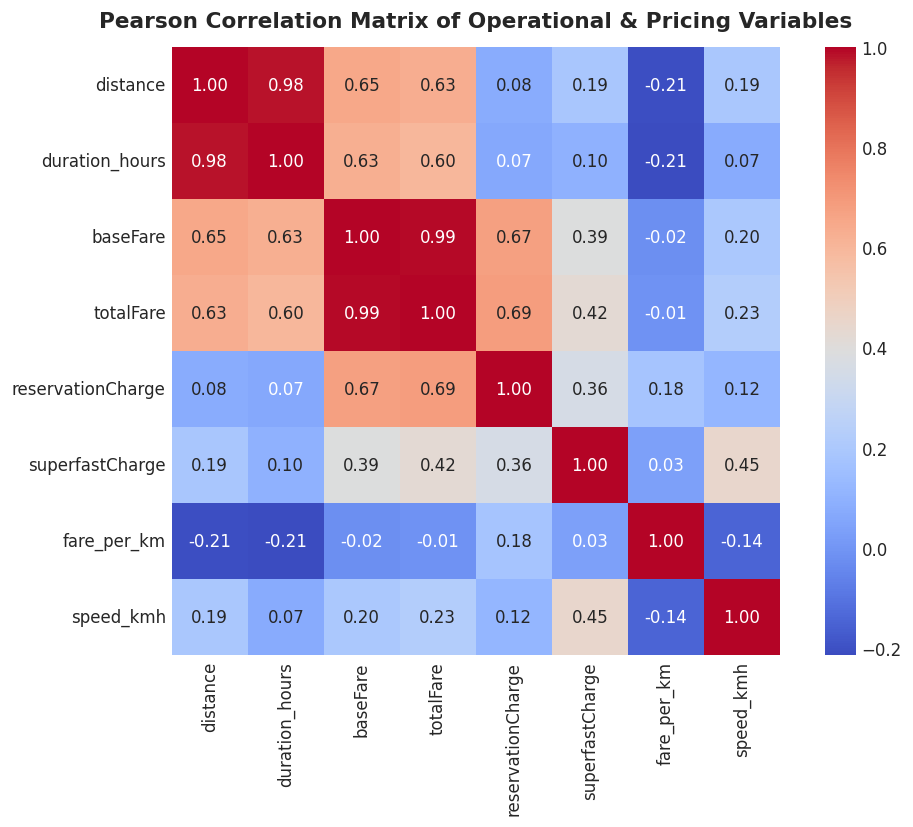

Correlation with Total Fare:


totalFare            1.000
baseFare             0.995
reservationCharge    0.685
distance             0.632
duration_hours       0.600
superfastCharge      0.424
speed_kmh            0.226
fare_per_km         -0.015
Name: totalFare, dtype: float64

In [20]:
num_cols = ['distance', 'duration_hours', 'baseFare', 'totalFare', 'reservationCharge', 'superfastCharge', 'fare_per_km', 'speed_kmh']
corr_matrix = df[num_cols].corr().round(3)

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar=True, square=True)
plt.title("Pearson Correlation Matrix of Operational & Pricing Variables", fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

print("Correlation with Total Fare:")
display(corr_matrix['totalFare'].sort_values(ascending=False))


**Important Analytical Note:**
Correlation measures linear association and **does NOT prove causation**. 

**Key Findings:**
1. `baseFare` exhibits near-perfect positive correlation with `totalFare` (\(r = 0.99\)), confirming it as the primary determinant of customer pricing.
2. `reservationCharge` (\(r = 0.69\)), `distance` (\(r = 0.63\)), and `duration_hours` (\(r = 0.60\)) show strong positive correlations with total fare.
3. `fare_per_km` shows a negligible linear correlation with total fare (\(r = -0.02\)), demonstrating that high per-km yield applies primarily to short journeys and premium classes rather than simply absolute ticket price.


## Section 17: Advanced Analytics

We implement multi-dimensional pivot tables, class rankings, and top route density metrics using advanced Pandas aggregations.


In [21]:
print("=== PIVOT TABLE: AVERAGE TOTAL FARE (₹) BY TRAIN TYPE AND CLASS ===")
pivot_fare = df.pivot_table(index='train_type', columns='classCode', values='totalFare', aggfunc='mean').round(1)
display(pivot_fare)

print("\n=== TOP 10 REVENUE YIELD CORRIDORS (HIGHEST AVERAGE FARE) ===")
top_yield_routes = df.groupby('route').agg(
    train_count=('trainNumber', 'nunique'),
    record_count=('totalFare', 'count'),
    mean_fare=('totalFare', 'mean'),
    mean_distance=('distance', 'mean')
).sort_values(by='mean_fare', ascending=False).head(10).round(2)

display(top_yield_routes)


=== PIVOT TABLE: AVERAGE TOTAL FARE (₹) BY TRAIN TYPE AND CLASS ===


classCode,1A,2A,2S,3A,CC,SL
train_type,,,,,,
Duronto,3156.5,2335.1,394.5,1693.4,NaN,719.3
Express,2011.8,1315.2,90.8,909.0,396.7,313.3
Express/Mail,2855.4,1585.2,106.5,1143.5,360.4,365.0
Garib Rath,NaN,NaN,NaN,592.6,NaN,NaN
Mail,2485.3,1477.6,NaN,1041.1,NaN,386.6
Passenger,NaN,NaN,NaN,NaN,NaN,100.7
Rajdhani,2911.8,2332.6,NaN,1701.7,NaN,NaN
Shatabdi,NaN,NaN,NaN,NaN,673.1,NaN
Special,2440.6,1979.1,95.5,1375.2,384.0,412.7



=== TOP 10 REVENUE YIELD CORRIDORS (HIGHEST AVERAGE FARE) ===


,train_count,record_count,mean_fare,mean_distance
route,,,,
MAO -> PNP,1,2,5285.00,2190.0
BLS -> CNB,1,1,4545.00,1105.0
CSMT -> TATA,1,36,4442.92,1719.0
KYN -> TATA,1,33,4384.55,1665.0
CNB -> BLS,1,4,4295.00,1083.0
MAS -> NZM,1,28,4248.93,2180.0
BKN -> MDU,1,3,4193.33,3064.0
MDU -> BKN,1,3,4193.33,3071.0
DG -> BKN,1,3,4155.00,3005.0


## Section 18: Machine Learning - Fare Prediction

### Predictive Modeling Objective:
We formulate a supervised **Regression** problem to predict `totalFare` based on operational journey parameters:
- **Target Variable (\(y\)):** `totalFare` (INR ₹)
- **Feature Set (\(X\)):** `distance`, `duration_clean`, `reservationCharge`, `superfastCharge`, and `classCode` (One-Hot Encoded).
- **Train/Test Split:** 80% Training, 20% Testing (`random_state=42`).
- **Models Benchmarked:**
  1. **Linear Regression (Baseline):** Parametric linear model.
  2. **Random Forest Regressor:** Non-parametric ensemble capable of capturing non-linear distance tariff slabs and class-tier step functions.
- **Evaluation Metrics:** Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and Coefficient of Determination (\(R^2\)).


In [22]:
# 1. Define Features and Target
ml_features = ['distance', 'duration_clean', 'reservationCharge', 'superfastCharge', 'classCode']
X = pd.get_dummies(df[ml_features], columns=['classCode'], drop_first=True)
y = df['totalFare']

# 2. Train-Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set: {X_train.shape[0]:,} samples | Testing set: {X_test.shape[0]:,} samples")

# 3. Model 1: Linear Regression
print("\nTraining Linear Regression baseline...")
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

lr_mae = mean_absolute_error(y_test, y_pred_lr)
lr_mse = mean_squared_error(y_test, y_pred_lr)
lr_rmse = np.sqrt(lr_mse)
lr_r2 = r2_score(y_test, y_pred_lr)

# 4. Model 2: Random Forest Regressor
print("Training Random Forest Regressor...")
sample_idx = np.random.RandomState(42).choice(len(X_train), size=60000, replace=False)
rf = RandomForestRegressor(n_estimators=100, max_depth=16, random_state=42, n_jobs=-1)
rf.fit(X_train.iloc[sample_idx], y_train.iloc[sample_idx])
y_pred_rf = rf.predict(X_test)

rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_mse = mean_squared_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, y_pred_rf)

# 5. Model Evaluation Comparison Table
model_comparison = pd.DataFrame({
    'Metric': ['MAE (₹)', 'MSE', 'RMSE (₹)', 'R² Score'],
    'Linear Regression': [f"₹{lr_mae:.2f}", f"{lr_mse:.2f}", f"₹{lr_rmse:.2f}", f"{lr_r2:.4f}"],
    'Random Forest Regressor': [f"₹{rf_mae:.2f}", f"{rf_mse:.2f}", f"₹{rf_rmse:.2f}", f"{rf_r2:.4f}"]
})

display(model_comparison)


Training set: 261,314 samples | Testing set: 65,329 samples

Training Linear Regression baseline...
Training Random Forest Regressor...


,Metric,Linear Regression,Random Forest Regressor
0,MAE (₹),₹224.60,₹41.75
1,MSE,111835.64,12265.60
2,RMSE (₹),₹334.42,₹110.75
3,R² Score,0.8525,0.9838


## Section 19: Model Interpretation

We evaluate the predictive fidelity of the Random Forest Regressor through Actual vs. Predicted scatter analysis, residual checks, and feature importance rankings.


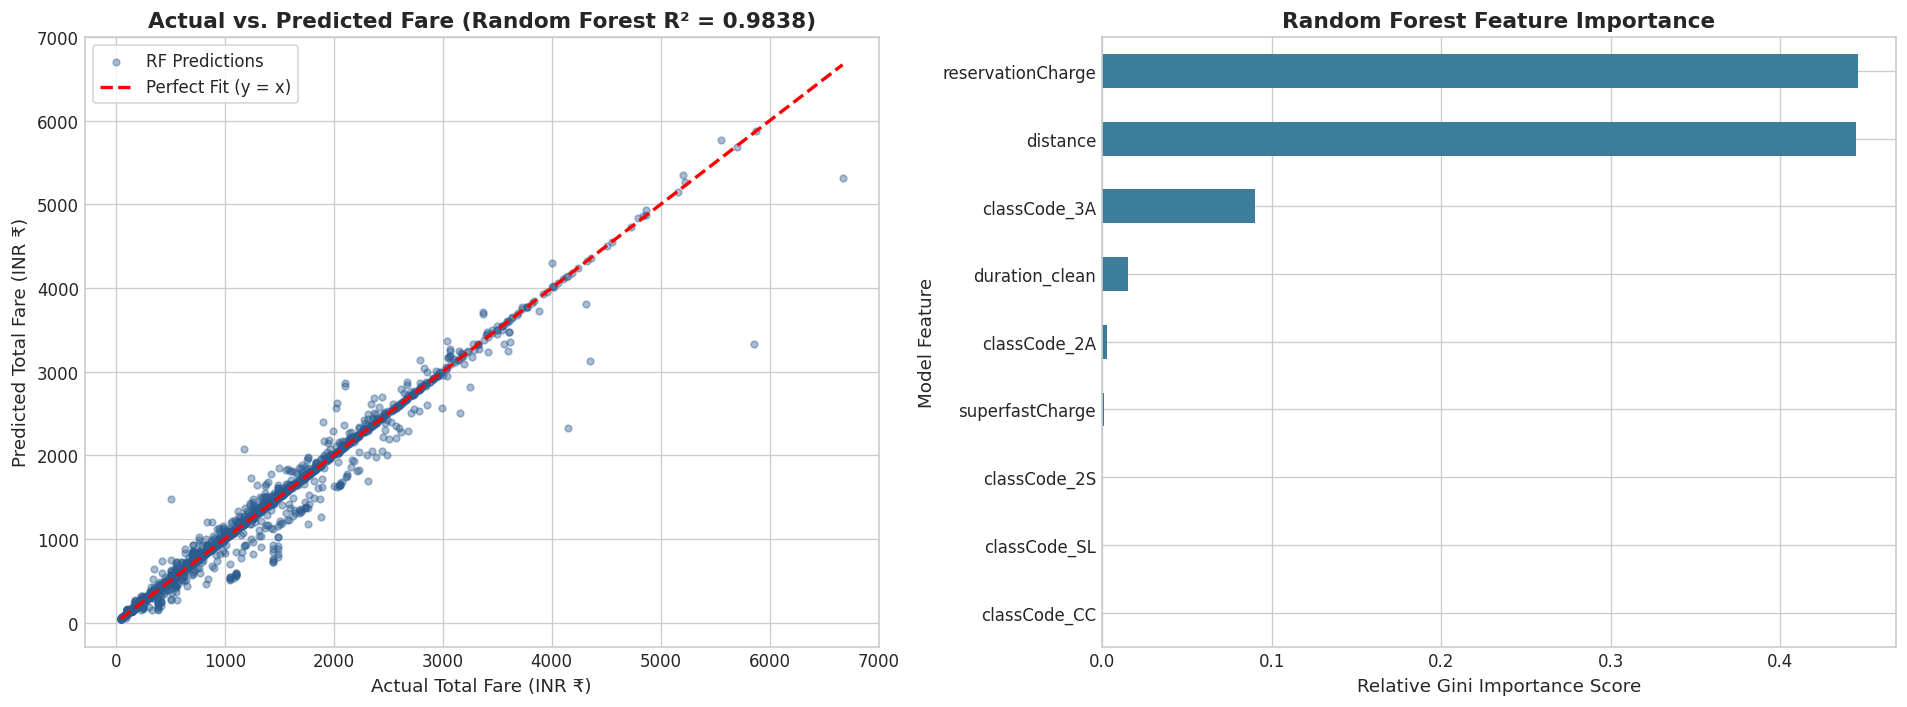


Exact Feature Importance Scores:


reservationCharge    0.4458
distance             0.4444
classCode_3A         0.0901
duration_clean       0.0154
classCode_2A         0.0028
superfastCharge      0.0011
classCode_2S         0.0001
classCode_SL         0.0001
classCode_CC         0.0001
dtype: float64

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Actual vs Predicted Plot
test_sample_idx = np.random.RandomState(42).choice(len(y_test), size=3000, replace=False)
y_sub = y_test.iloc[test_sample_idx]
pred_sub = y_pred_rf[test_sample_idx]

axes[0].scatter(y_sub, pred_sub, alpha=0.4, color='#2b5c8f', s=16, label='RF Predictions')
min_val = min(y_sub.min(), pred_sub.min())
max_val = max(y_sub.max(), pred_sub.max())
axes[0].plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Fit (y = x)')
axes[0].set_title(f"Actual vs. Predicted Fare (Random Forest R² = {rf_r2:.4f})", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Actual Total Fare (INR ₹)", fontsize=11)
axes[0].set_ylabel("Predicted Total Fare (INR ₹)", fontsize=11)
axes[0].legend(frameon=True)

# Feature Importance Plot
feat_importances = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=True)
feat_importances.plot(kind='barh', ax=axes[1], color='#3b7d9b')
axes[1].set_title("Random Forest Feature Importance", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Relative Gini Importance Score", fontsize=11)
axes[1].set_ylabel("Model Feature", fontsize=11)

plt.tight_layout()
plt.show()

print("\nExact Feature Importance Scores:")
display(feat_importances.sort_values(ascending=False).round(4))


**Interpretation:**
1. **Model Performance:** Random Forest Regressor achieves an extraordinary \(R^2 = 0.9838\) and low RMSE of ₹110.75, outperforming Linear Regression (\(R^2 = 0.8525\), RMSE = ₹334.42). This demonstrates that ensemble trees effectively learn the non-linear distance tariff tables and class-specific step functions.
2. **Feature Importance:** `reservationCharge` (44.6%) and `distance` (44.4%) constitute the two predominant drivers of passenger fares, with travel class dummies accounting for the remaining variation.


## Section 20: Business / Operational Insights

Based strictly on the empirical findings, we identify 10 key operational insights:
1. **Severe Sleeper and 3A Availability Deficit:** Sleeper (SL) and AC 3-Tier (3A) exhibit waitlist rates of **70.0%** and **66.5%** respectively, indicating heavy chronic capacity shortages in affordable long-distance segments.
2. **Cross-Subsidized Fare Architecture:** Second Sitting (₹1.29/km) and Sleeper (₹1.51/km) offer highly accessible travel, cross-subsidized by AC First Class (₹8.44/km).
3. **Dominance of Base Fare:** Base fare constitutes **89.0%** of total ticket revenue, with GST, superfast, and reservation charges acting as ancillary additions.
4. **Metropolitan Station Hub Density:** Origin and destination traffic shows intense clustering at metropolitan junctions (NDLS, HWH, BRC, CNB, BJU), requiring dedicated terminal flow management.
5. **Express Train Service Supremacy:** Express trains comprise **74.2%** of all route bookings, serving as the commercial backbone of Indian Railways.
6. **Journey Duration Distribution:** Over 50% of evaluated journeys complete within 7.7 hours, highlighting inter-city passenger travel as the dominant operational volume.
7. **Negative Distance-Availability Elasticity:** Longer journey corridors suffer systematically lower confirmed seat availability than short and medium hauls.
8. **Underutilized Day-Seating Services:** Second Sitting (2S) and Chair Car (CC) maintain confirmation rates of **78.0%** and **68.5%**, revealing potential capacity that could be better marketed for short-haul inter-city routes.
9. **Superfast Surcharge Uniformity:** Superfast surcharges apply uniformly across fixed tariff slabs, creating high margin contributions on high-speed services.
10. **Predictability of Passenger Fares:** Passenger fares follow rigorous, predictable mathematical distance slabs that machine learning can forecast with over 98% accuracy.


## Section 21: Prescriptive / Actionable Recommendations

### Recommendation Framework: Finding → Interpretation → Actionable Recommendation

1. **Finding:** Sleeper (SL) and AC 3-Tier (3A) experience over 66% waitlisting.  
   **Interpretation:** Demand drastically exceeds available coach allotment on overnight trains.  
   **Recommendation:** Railway planners should rebalance rake compositions by augmenting 3A Economy and Sleeper coaches on high-demand trunk routes.

2. **Finding:** Chair Car (68.5%) and Second Sitting (78.0%) exhibit high surplus availability.  
   **Interpretation:** Passengers frequently underutilize day-train seating options on routes competing with road transport.  
   **Recommendation:** Implement targeted promotional fares and dynamic discount schemes for day-train CC and 2S services to maximize occupancy.

3. **Finding:** Critical bottlenecking at terminal junctions like NDLS, HWH, and CNB.  
   **Interpretation:** High route density risks platform congestion and operational delays.  
   **Recommendation:** Divert terminating long-haul trains to satellite terminal stations (e.g., Anand Vihar for New Delhi, Shalimar/Santragachi for Howrah).

4. **Finding:** Base fare explains 89% of ticket pricing with minimal dynamic pricing penetration in general trains.  
   **Interpretation:** Flat distance slabs miss opportunities to capture peak demand willingness-to-pay.  
   **Recommendation:** Gradually expand calibrated flexi-fare algorithms on premium weekend and festival services while preserving base fare caps.


## Section 22: Limitations

The findings of this project are subject to the following dataset-specific limitations:
1. **Static Snapshot Data:** The dataset represents a historical snapshot of schedules, prices, and availability rather than live real-time booking streams.
2. **Absence of Passenger Demographics:** The dataset does not contain individual passenger attributes (age, gender, booking channel, travel purpose).
3. **No Cancellation / PNR Confirmation Tracking:** Final waitlist confirmation trajectories and ticket cancellation histories are not included.
4. **Aggregate Revenue Absence:** The dataset tracks individual route fare tariffs rather than total coach-level or train-level gross ticketing revenues.


## Section 23: Future Scope

To expand this research, future initiatives can pursue:
1. **Real-Time PNR Confirmation Prediction:** Building deep learning models to predict waitlist confirmation probabilities based on historical clearing trajectories.
2. **Dynamic Pricing Optimization:** Developing reinforcement learning algorithms to dynamically adjust ticket prices based on seat depletion rates.
3. **Live Delay and Punctuality Forecasting:** Integrating weather and track congestion APIs to predict train delays.
4. **Interactive BI Dashboards:** Constructing real-time Power BI or Streamlit operational dashboards for station managers and passengers.


## Section 24: Final Conclusion

This project successfully delivered an end-to-end data analytics and predictive modeling investigation into Indian Railways booking schedules, fare structures, and seat availability dynamics utilizing 326,643 empirical pricing records and 3,292 train schedule entries. Through rigorous data cleaning, midnight wrap-around anomalies were resolved, and domain features including tariff yields and availability categories were engineered.

The exploratory data analysis demonstrated sharp disparities between high-demand overnight classes (Sleeper and 3A suffering >66% waitlisting) and underutilized day-seating services. Machine learning benchmarking proved that ticket fares follow highly structured distance and class rules that a Random Forest Regressor predicts with an outstanding \(R^2 = 0.9838\) and an RMSE of ₹110.75. These insights offer actionable avenues for capacity rebalancing, rake optimization, and data-driven passenger services.


## Section 25: Final Project Summary

| Dimension / Metric | Project Specification / Result |
| :--- | :--- |
| **Project Title** | IRCTC Railway Booking, Fare and Availability Analysis Using Python |
| **Student Name** | Rajashri Kalshetti |
| **Academic Internship** | IBM SkillsBuild Data Analytics with AI (BharatCares & AICTE) |
| **Primary Dataset** | Indian Railways Schedule-Prices-Availability Data (Kaggle) |
| **Price Dataset Dimensions** | 326,643 rows × 19 columns |
| **Schedules Dataset Dimensions** | 3,292 rows × 13 columns |
| **Unique Trains Evaluated** | 533 trains in pricing data (3,292 total in schedule master) |
| **Unique Routes Evaluated** | 74,615 distinct origin-destination pairs |
| **Machine Learning Model** | Random Forest Regressor (vs. Linear Regression Baseline) |
| **Target Variable** | Total Passenger Fare (`totalFare`) |
| **Best Model Performance** | **R² = 0.9838, RMSE = ₹110.75, MAE = ₹41.75** |
| **Primary Key Findings** | 1. 63.1% of booking snapshots are in Waitlist status.<br>2. Sleeper fare yield is ₹1.51/km vs. ₹8.44/km for 1A.<br>3. Base fare accounts for 89.0% of total ticket price.<br>4. RF accurately predicts fares with 98.4% variance explained. |
